In [ ]:
# Install required packages
!pip install --upgrade --quiet playwright
!pip install --upgrade --quiet beautifulsoup4
!pip install --upgrade --quiet lxml
!pip install --upgrade --quiet html5lib
!pip install --upgrade --quiet pandas
!pip install --upgrade --quiet nest_asyncio

print('✓ Packages installed!')

**Slides:** [browser-automation.pdf](./browser-automation.pdf)

In this example we are going to scrape the [OpenSyllabus works page](https://analytics.opensyllabus.org/record/works) for books included on college syllabi.

Traditionally Python programmers use [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) to scrape content from the interent. Instead of being *traditional*, we're going to use [Playwright](https://playwright.dev/python/), a **browser automation tool**! This means you actually control the browser! Filling out forms, clicking buttons, downloading documents... it's magic!!!✨✨✨

# OpenSyllabus works list

## What we'll learn/use

- Selectors
- 'Show more' button pagination
- Creating and saving a dataframe

## Installation

We need to install a few tools first! Remove the `#` and run the cell to install the Python packages and browsers that we'll need for our scraping adventure.

In [1]:
# %pip install --quiet lxml html5lib beautifulsoup4 pandas
# %pip install --quiet playwright
# !playwright install-deps
# !playwright install chromium firefox

We'll also set it up so that Playwright works well in Windows on a Jupyter notebook.

In [2]:
# Detect if we're running in Google Colab
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

import platform
import asyncio
import nest_asyncio

if platform.system() == "Windows":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
except RuntimeError:
    pass

## Requests + BS4 = doesn't work

First, let's see what it looks like when we're scraping a "normal" site. You grab the page, you tell BeautifulSoup what you want, you get it.

In [3]:
import requests
from bs4 import BeautifulSoup

response = requests.get("https://bbc.com")
doc = BeautifulSoup(response.text)
headlines = doc.find_all('h2')
headlines[:5]

[<h2 class="sc-feaf8701-3 cCnzGv" data-testid="card-headline">Israel attacks presidential office in Tehran as reported death toll in Iran rises to 787</h2>,
 <h2 class="sc-93f35dd3-4 fQIzBA" data-testid="texas-title">WATCH</h2>,
 <h2 class="sc-feaf8701-3 goAeMP" data-testid="card-headline">BBC questions Marco Rubio over reported strike on Iranian school</h2>,
 <h2 class="sc-feaf8701-3 goAeMP" data-testid="card-headline">Devastation on Tehran street after strike</h2>,
 <h2 class="sc-feaf8701-3 goAeMP" data-testid="card-headline">Texas Trump supporters react to US strikes on Iran </h2>]

But now let's try it with a site that does *not* work with this "normal" approach to scraping. We'll be using the [OpenSyllabus works page](https://analytics.opensyllabus.org/record/works).

In [4]:
import requests
from bs4 import BeautifulSoup

response = requests.get("https://analytics.opensyllabus.org/record/works")
doc = BeautifulSoup(response.text)

No errors yet, but let's try to find some book titles... 

In [5]:
doc.find_all(class_='sc-9d100f21-9 bNgiIK')

[]

No luck! But maybe our `class_=` magic is wrong? Who even knows how that works? We can use `doc.text` to look at alllllllll of the text on the page.

In [6]:
print(doc.text)

Open Syllabus Analytics


Looks like **the content isn't even on the page**. Now we can move on to *Playwright!*

## Opening up the browser and visiting our destination

In the example below, we can choose a setting for `headless`.

- `headless=True` means "hide the browser"
- `headless=False` means "show the browser"

In [7]:
from playwright.async_api import async_playwright

# "Hey, open up a browser"
playwright = await async_playwright().start()

# Colab can't open a visible browser, so we run headless there
if IN_COLAB:
    use_headless = True
else:
    use_headless = False

browser = await playwright.chromium.launch(headless=use_headless)

# Create a new browser window
page = await browser.new_page()

In [8]:
await page.goto("https://analytics.opensyllabus.org/record/works")

<Response url='https://analytics.opensyllabus.org/record/works' request=<Request url='https://analytics.opensyllabus.org/record/works' method='GET'>>

If you run headless, you often want to take a screenshot to confirm what's going on in your scraping world. **I usually recommend using `headless=False` until you confirm your scraper works,** then change it to headless mode so it doesn't get in the way.

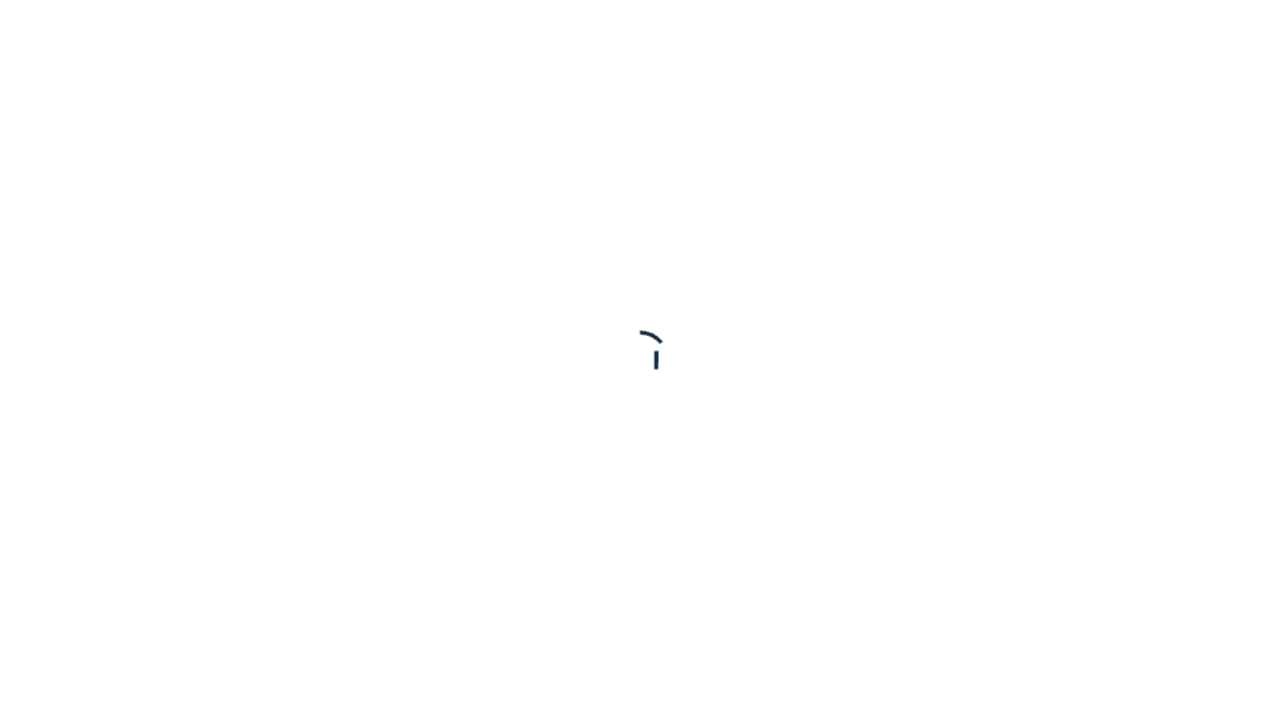

In [9]:
from IPython.display import Image

Image(await page.screenshot())

## Clicking load more buttons

The page that we're looking at has plenty of data, but there's more in hiding – if you scroll to the bottom of the page you'll see a "Show more" button.

Let's grab it using `page.get_by_text` and click it.

In [10]:
await page.get_by_text("Show more").click()

Again! and again! And again! Let's click it **five more times**.

We'll wait one second between each click so it doesn't accidentally double-click the button.

In [11]:
import time

for i in range(5):
    await page.get_by_text("Show more").click(timeout=5000)
    print(f"Clicked, waiting 2 seconds...")
    time.sleep(2)

Clicked, waiting 2 seconds...


Clicked, waiting 2 seconds...


Clicked, waiting 2 seconds...


Clicked, waiting 2 seconds...


Clicked, waiting 2 seconds...


If you replaced the `for i in range` with `while True` it would click forever and ever. Eventually the "Show more" button runs out and there's no more button on the page: Playwright will wait for "Show more" for 30 seconds before returning an error.

## Grab the content from the page

Now we need to get the *content* from the page. Everyone loves using BeautifulSoup to scrape, so why don't we just do that? You use `await page.content()` to save the contents of the page and feed it directly to BeautifulSoup.

In [12]:
from bs4 import BeautifulSoup

html = await page.content()
doc = BeautifulSoup(html)

Once you push the HTML from the Playwright page into BeautifulSoup, you can use all the same selectors and filters that you can in your "normal" scraping world.

In [13]:
titles = doc.find_all(class_='sc-9d100f21-9')
for title in titles[:10]:
    print(title.text)

Calculus
The Elements of Style
Social Research Methods
Human Anatomy and Physiology Laboratory Manual
English Grammar in Use
Research Design
Doing Your Research Project: A Guide for First-Time Researchers in Education and Social Science
Biology
A Manual for Writers of Research Papers, Theses, and Dissertations: Chicago Style for Students and Researchers
The Study Skills Handbook


## Developing your selectors

Let's be honest: **writing custom scraping code isn't anyone's favorite thing to do.**

To put together your selectors to grab the "right" data, I suggest using [my ChatGPT prompt](https://chatgpt.com/share/69a2f31d-727c-800d-b3ca-65a32a714336) to help. You can see the [original prompt here](https://gist.github.com/jsoma/d46ba769764866331a83d702a3054751) if you'd like to use it with another AI tool.

You want to right-click the data you're interested in, then select **Inspect**. That provides two approaches to finding your region of interest: either browsing around on the right-hand side...

<img src="finding-row-1.gif" style="max-width: 600px">

...or using the element selector and clicking on the left-hand side.

<img src="finding-row-2.gif" style="max-width: 600px">

[Pandas](https://pandas.pydata.org/) is the Python equivalent to Excel, and it's great at dealing with tabular data! If you can build a list of dictionaries it's fantastic for saving the content.

In [14]:
import pandas as pd

rows = []
for tr in doc.select("tr.sc-9d100f21-6"):
    row = {}

    try:
        row["rank"] = tr.select_one("p.sc-9d100f21-7").get_text(strip=True)
    except:
        pass

    try:
        row["title"] = tr.select_one("a[href^='/singleton/works'] p").get_text(strip=True)
    except:
        pass

    try:
        row["author"] = tr.select_one("a[href^='/singleton/authors'] p").get_text(strip=True)
    except:
        pass

    try:
        row["score"] = tr.select_one("div[name='score-star'] + p").get_text(strip=True)
    except:
        pass

    try:
        row["appearances"] = tr.select_one("div.elzFcv").get_text(strip=True)
    except:
        pass

    rows.append(row)

df = pd.DataFrame(rows)
df.head(10)

,rank,title,author,score
0,1,Calculus,James Stewart,100
1,2,The Elements of Style,William Strunk,100
2,3,Social Research Methods,Alan Bryman,100
3,4,Human Anatomy and Physiology Laboratory Manual,Elaine Nicpon Marieb,100
4,5,English Grammar in Use,Raymond Murphy,100
5,6,Research Design,John W Creswell,100
6,7,Doing Your Research Project: A Guide for First...,Judith Bell,100
7,8,Biology,Neil Alexander Campbell,100
8,9,"A Manual for Writers of Research Papers, These...",Kate L Turabian,100
9,10,The Study Skills Handbook,Stella Cottrell,100


We clicked and clicked and clicked. How far down the list did we get? 

In [15]:
df.tail(10)

,rank,title,author,score
290,291,Using and Understanding Mathematics: A Quantit...,Jeffrey O Bennett,90
291,292,"Supply Chain Management: Strategy, Planning, a...",Sunil Chopra,93
292,293,Confessions,Augustine,88
293,294,Management and Cost Accounting,Colin Drury,92
294,295,Design Patterns: Elements of Reusable Object-O...,Erich Gamma,91
295,296,Data Mining: Concepts and Techniques,Jiawei Han,93
296,297,Microbiology: An Introduction,Gerard J Tortora,90
297,298,America,David E Shi,96
298,299,The C++ Programming Language,Bjarne Stroustrup,91
299,300,Culture and Imperialism,Edward W Said,91


## Saving the file

Now we can save our pandas dataframe to a CSV to open up in Excel or wherever else!

In [16]:
df.to_csv("books.csv", index=False)